**Problem-1**

**1.a**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


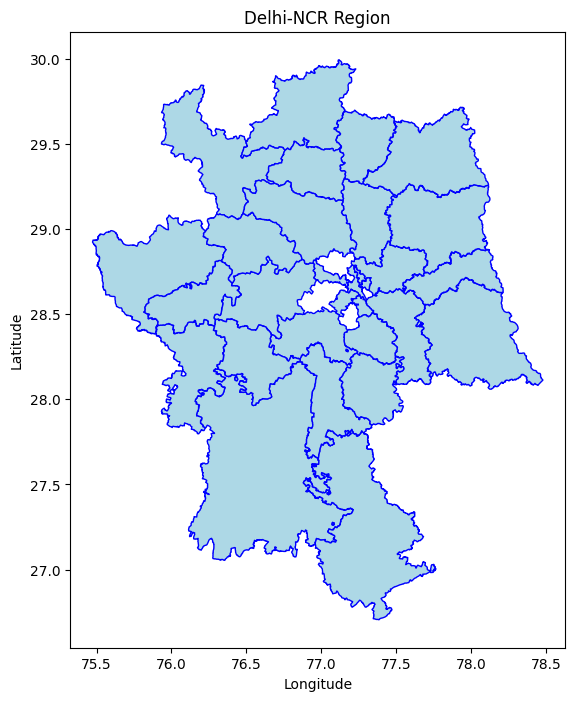

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

ncr_file = "/content/delhi_ncr_region.geojson"

ncr_gdf = gpd.read_file(ncr_file)

fig, ax = plt.subplots(figsize=(8, 8))
ncr_gdf.plot(ax=ax, facecolor='lightblue', edgecolor='blue')
ax.set_title("Delhi-NCR Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**1.b**

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.4 MB/s eta 0:00:00


In [ ]:
import geemap
import ee

ee.Authenticate()
ee.Initialize(project='celestial-gecko-477209-u8')

airshed_file = "/content/delhi_airshed.geojson"

Map = geemap.Map(center=[28.70, 77.10], zoom=9)
Map.add_basemap("SATELLITE")

style = {'color': 'yellow', 'fillColor': '00000000', 'width': 2}
Map.add_geojson(airshed_file, style=style, layer_name="Delhi Airshed")

Map

Map(center=[28.7, 77.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

**1.c**

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 86.5 MB/s eta 0:00:00


In [ ]:
import ee
import geopandas as gpd
import geemap
import numpy as np
from shapely.geometry import Polygon
import os
import time

def get_active_tasks_count():
    try:
        operations = ee.data.listOperations()
        active_count = 0
        for op in operations:
            state = op.get('metadata', {}).get('state')
            if state in ['RUNNING', 'READY']:
                active_count += 1
        return active_count
    except Exception as e:
        print(f"Warning: Could not get GEE task list: {e}.")
        return 3000

def download_delhi_airshed_tiles():
    AIRSHED_SHP_PATH = '/content/delhi_airshed.geojson'
    GRID_CRS = "EPSG:32644"
    TILE_SIZE_METERS = 1280
    OUTPUT_DRIVE_FOLDER = "Delhi_Airshed_Tiles_JRF"
    GEE_TASK_LIMIT = 2950
    BATCH_SIZE = 250
    BATCH_SLEEP_SECONDS = 300

    # --- Initialization ---
    try:
        ee.Authenticate()
        ee.Initialize(project='celestial-gecko-477209-u8')
    except ee.ee_exception.EEException as e:
        print(f"GEE initialization failed: {e}")
        return

    print("GEE initialized successfully.")

    if not os.path.exists(AIRSHED_SHP_PATH):
        print(f"Error: Shapefile not found at '{AIRSHED_SHP_PATH}'")
        return

    print(f"Loading shapefile from {AIRSHED_SHP_PATH}...")
    airshed_gpd = gpd.read_file(AIRSHED_SHP_PATH)

    if airshed_gpd.crs is None:
        airshed_gpd.set_crs("EPSG:4326", inplace=True)

    airshed_ee = geemap.geopandas_to_ee(airshed_gpd)
    airshed_utm = airshed_gpd.to_crs(GRID_CRS)

    # --- Grid Generation ---
    xmin, ymin, xmax, ymax = airshed_utm.total_bounds
    x_coords = np.arange(np.floor(xmin), np.ceil(xmax) + TILE_SIZE_METERS, TILE_SIZE_METERS)
    y_coords = np.arange(np.floor(ymin), np.ceil(ymax) + TILE_SIZE_METERS, TILE_SIZE_METERS)

    grid_polygons = []
    for x in x_coords[:-1]:
        for y in y_coords[:-1]:
            grid_polygons.append(Polygon([
                (x, y), (x + TILE_SIZE_METERS, y),
                (x + TILE_SIZE_METERS, y + TILE_SIZE_METERS), (x, y + TILE_SIZE_METERS)
            ]))

    grid_gdf = gpd.GeoDataFrame(geometry=grid_polygons, crs=GRID_CRS)
    grid_to_export = gpd.sjoin(grid_gdf, airshed_utm, how="inner", predicate="intersects")
    grid_to_export = grid_to_export.drop_duplicates(subset=['geometry'])

    total_tiles = len(grid_to_export)
    print(f"--- Total images to download: {total_tiles} ---")
    if total_tiles == 0:
        print("Error: No grid cells intersect the airshed. Check CRS and shapefile.")
        return

    # --- Image Prep ---
    s2_collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(airshed_ee.geometry())
        .filterDate("2025-01-01", "2025-01-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50))
    )

    if s2_collection.size().getInfo() == 0:
        print("Error: No Sentinel-2 images found for January 2025 with < 50% cloud cover.")
        return

    s2_image = s2_collection.median()
    s2_image_rgb = s2_image.select(["B4", "B3", "B2"])

    print(f"Starting export tasks to Google Drive folder: '{OUTPUT_DRIVE_FOLDER}'")

    # --- Export Loop ---
    tasks_submitted = 0
    for index, tile in grid_to_export.iterrows():

        while True:
            active_tasks = get_active_tasks_count()
            if active_tasks < GEE_TASK_LIMIT:
                break
            else:
                print(f"  [PAUSING - HARD LIMIT] Task queue is full ({active_tasks} tasks).")
                time.sleep(300)

        if tasks_submitted > 0 and tasks_submitted % BATCH_SIZE == 0:
            print("  ---")
            print(f"  [PAUSING - BATCH LIMIT] Submitted {tasks_submitted} tasks.")
            print(f"  Sleeping for {BATCH_SLEEP_SECONDS // 60} minutes to rest the queue...")
            print("  ---")
            time.sleep(BATCH_SLEEP_SECONDS)

        tile_geometry = tile.geometry
        centroid = tile_geometry.centroid
        filename = f"tile_{int(round(centroid.x))}_{int(round(centroid.y))}"

        tile_gdf_for_ee = gpd.GeoDataFrame([{'geometry': tile_geometry}], crs=GRID_CRS)
        ee_region = geemap.geopandas_to_ee(tile_gdf_for_ee).geometry()

        task = ee.batch.Export.image.toDrive(
            image=s2_image_rgb,
            description=f"Export_{filename}",
            folder=OUTPUT_DRIVE_FOLDER,
            fileNamePrefix=filename,
            region=ee_region,
            scale=10,
            crs=GRID_CRS,
            maxPixels=1e9
        )

        task.start()
        tasks_submitted += 1

        if tasks_submitted % 50 == 0:
            print(f"  Submitted task {tasks_submitted} of {total_tiles}...")

    print(f"All {tasks_submitted} export tasks have been successfully submitted.")
    print("Please go to the GEE Code Editor 'Tasks' tab to review and execute the exports.")

if __name__ == "__main__":
    download_delhi_airshed_tiles()


GEE initialized successfully.
Loading shapefile from /content/delhi_airshed.geojson...
--- Total images to download: 4373 ---
Starting export tasks to Google Drive folder: 'Delhi_Airshed_Tiles_JRF'
  Submitted task 50 of 4373...
  Submitted task 100 of 4373...
  Submitted task 150 of 4373...
  Submitted task 200 of 4373...
  Submitted task 250 of 4373...
  ---
  [PAUSING - BATCH LIMIT] Submitted 250 tasks.
  Sleeping for 5 minutes to rest the queue...
  ---
  Submitted task 300 of 4373...
  Submitted task 350 of 4373...
  Submitted task 400 of 4373...
  Submitted task 450 of 4373...
  Submitted task 500 of 4373...
  ---
  [PAUSING - BATCH LIMIT] Submitted 500 tasks.
  Sleeping for 5 minutes to rest the queue...
  ---
  Submitted task 550 of 4373...
  Submitted task 600 of 4373...


KeyboardInterrupt: 

Dataset folder - https://drive.google.com/drive/folders/1SINtA3zQsqgCAtg9AFmobl-DCcX6ehvq?usp=sharing

Visulal plots of some downloaded images


Starting plot for 4 tiles with a 0 to 2500 stretch...


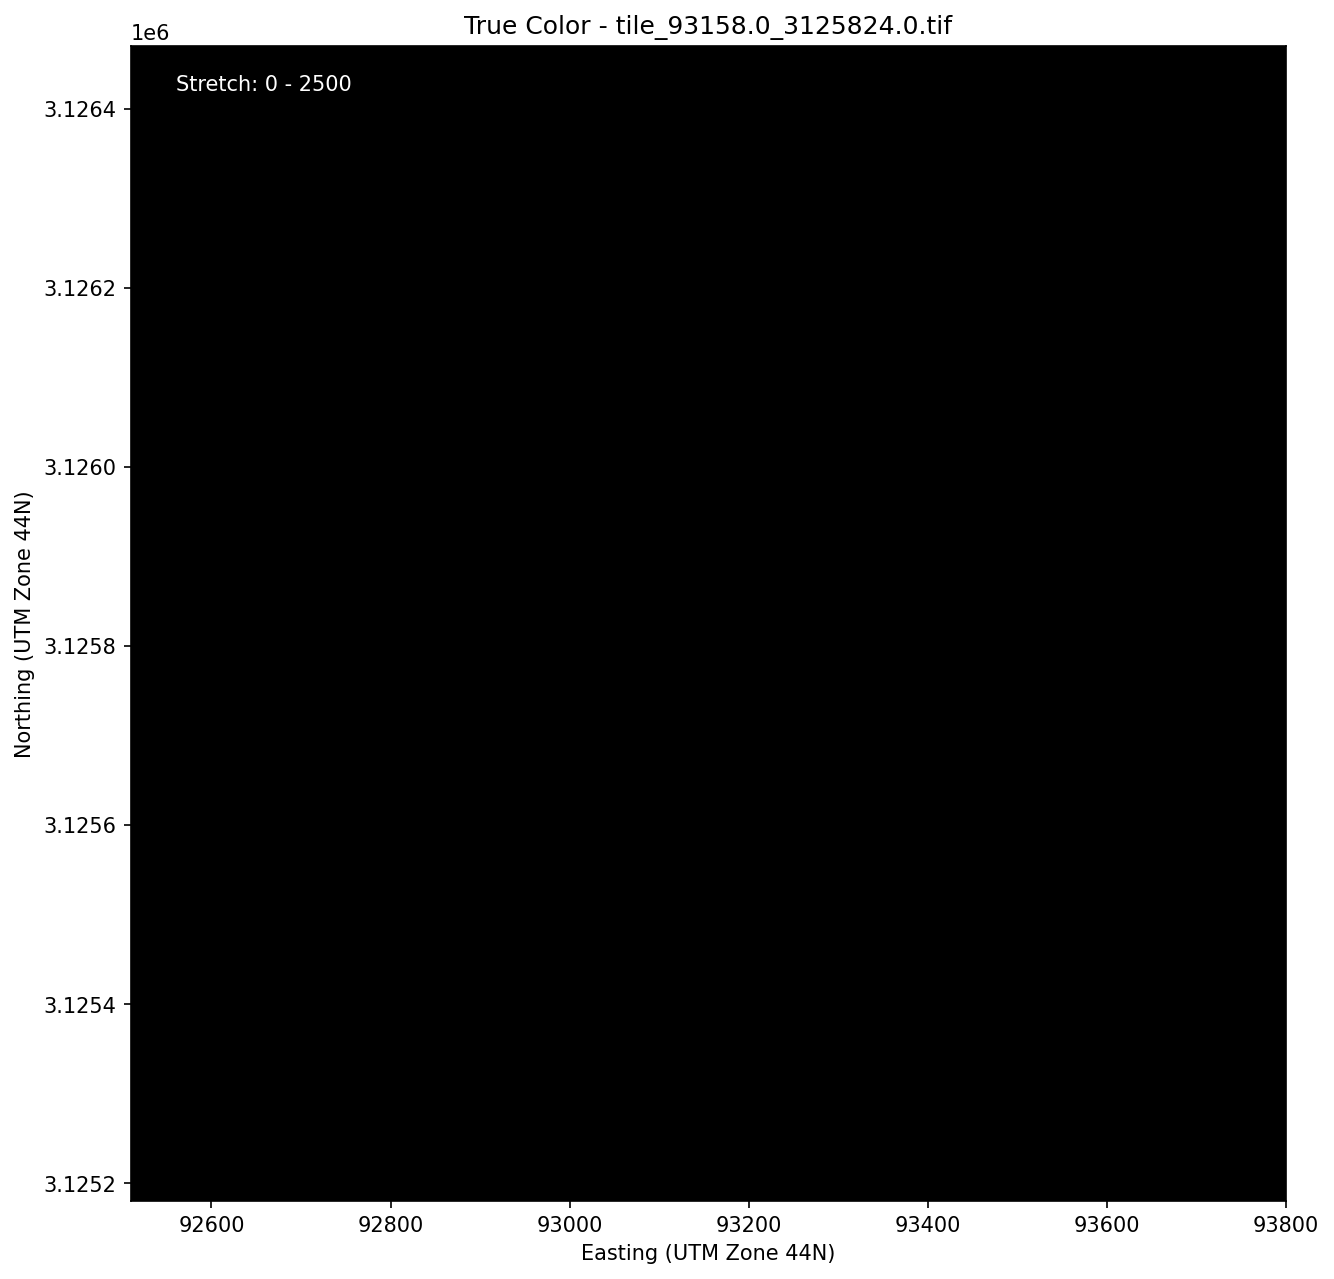

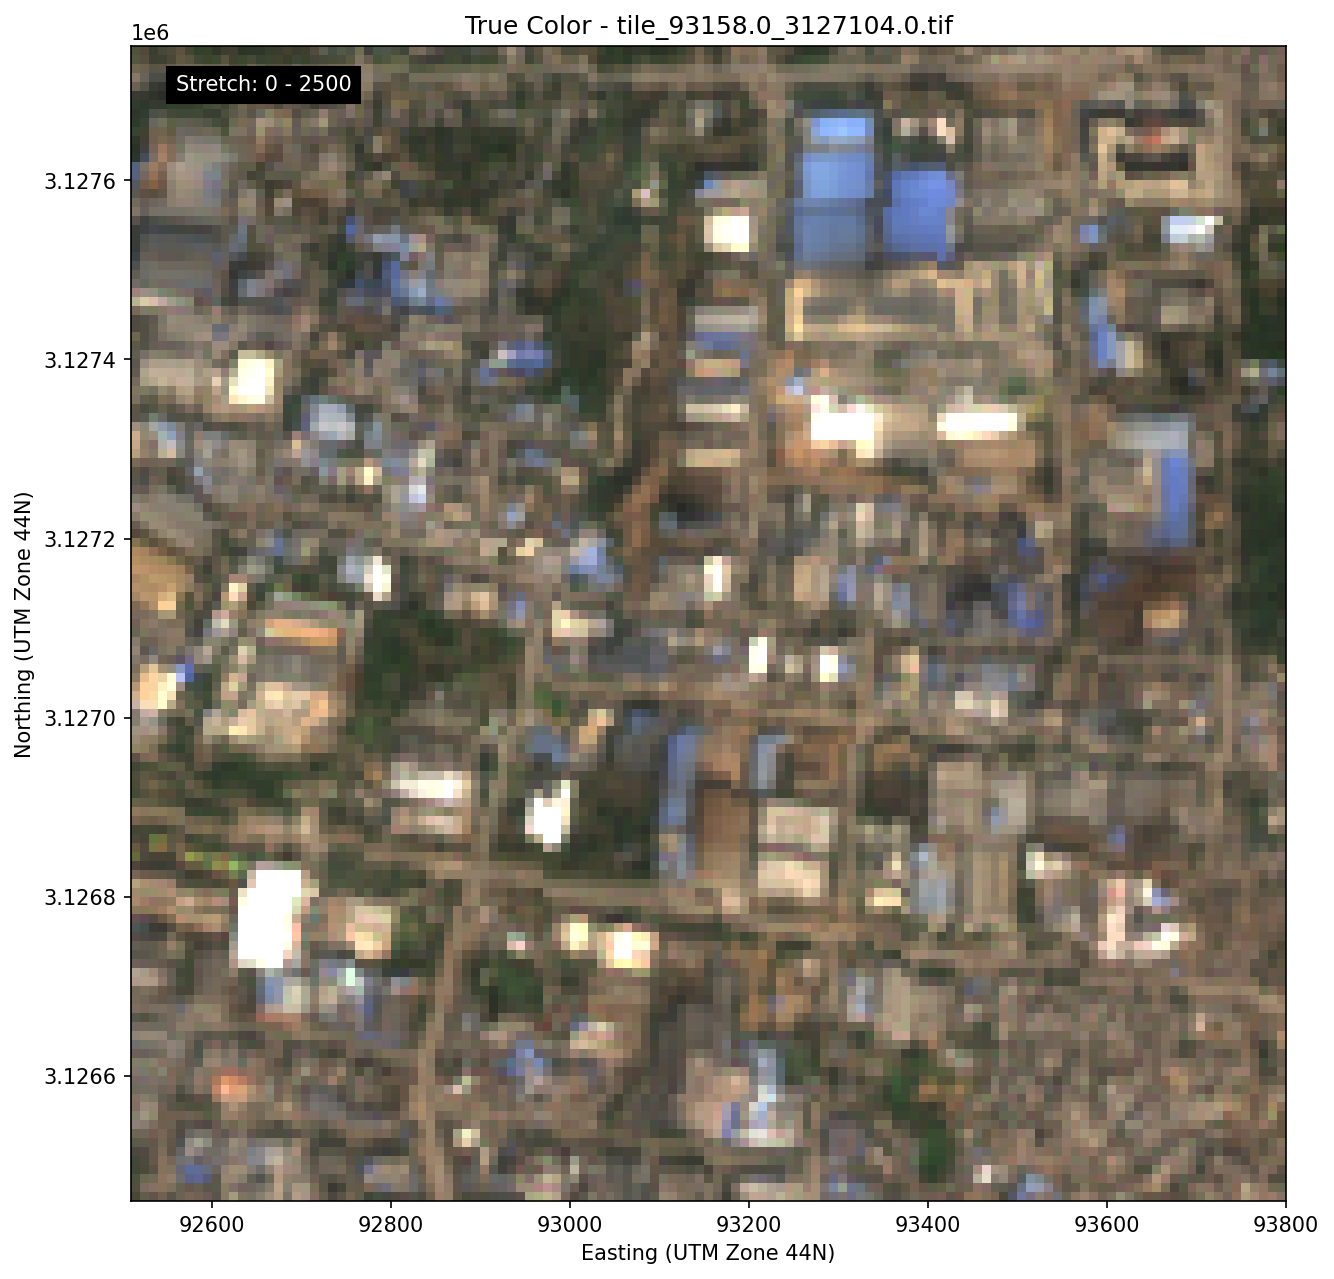

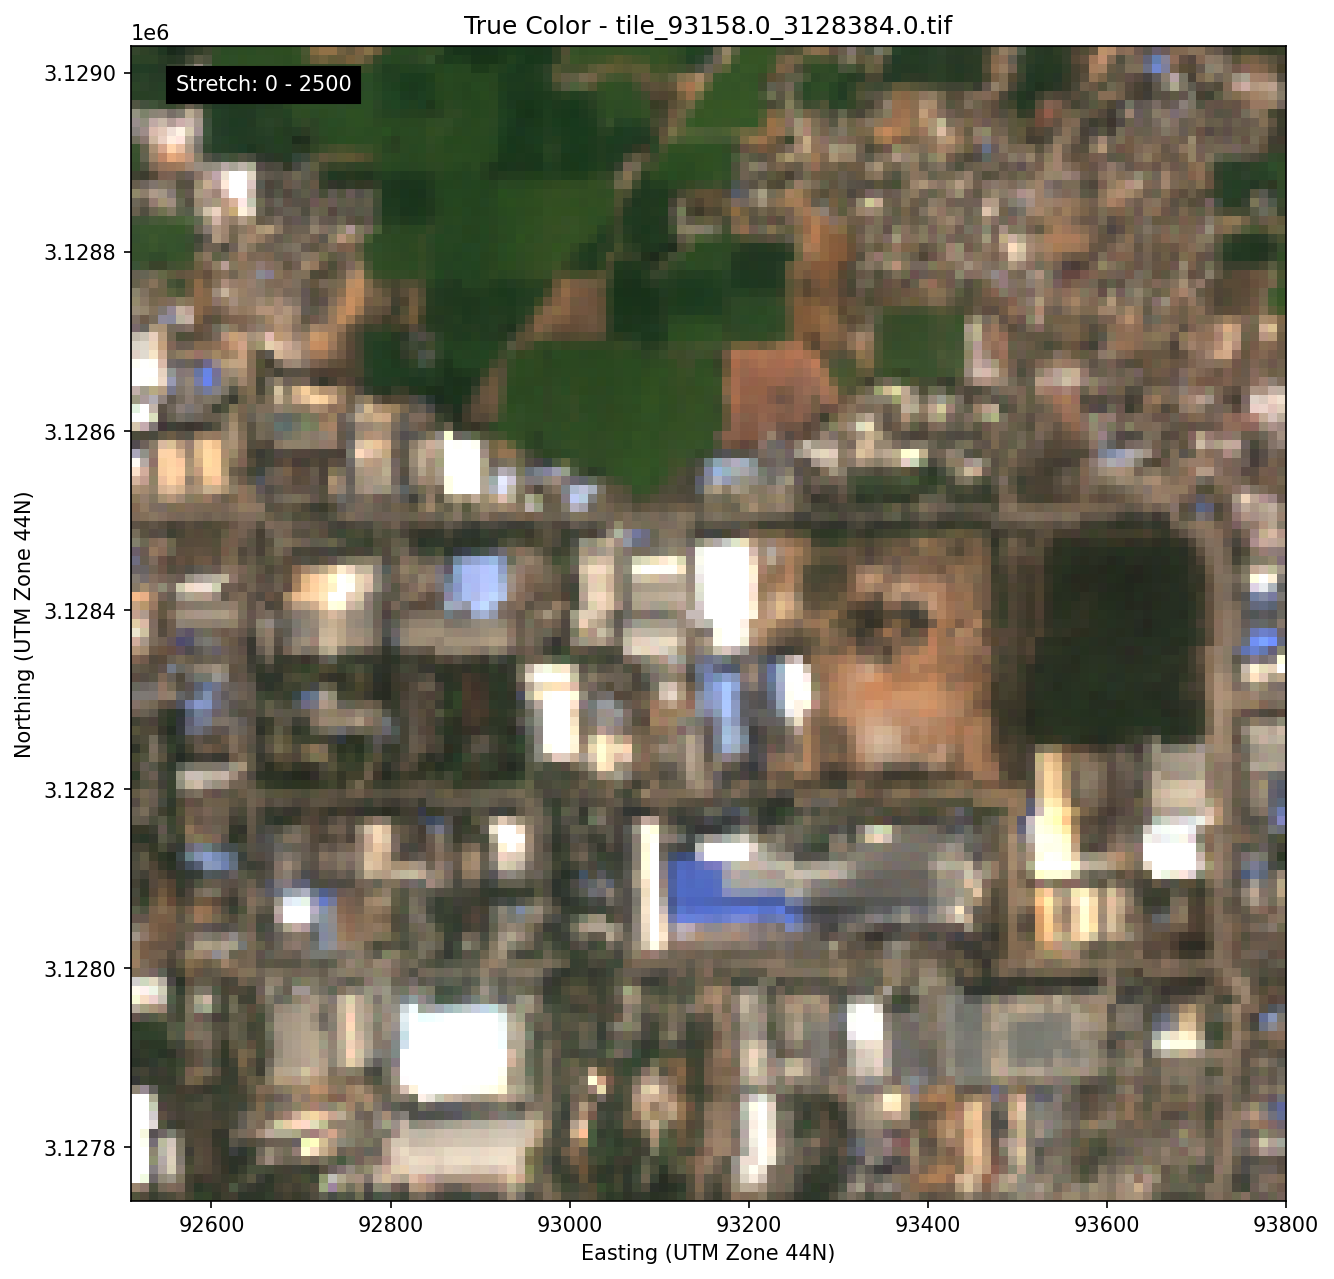

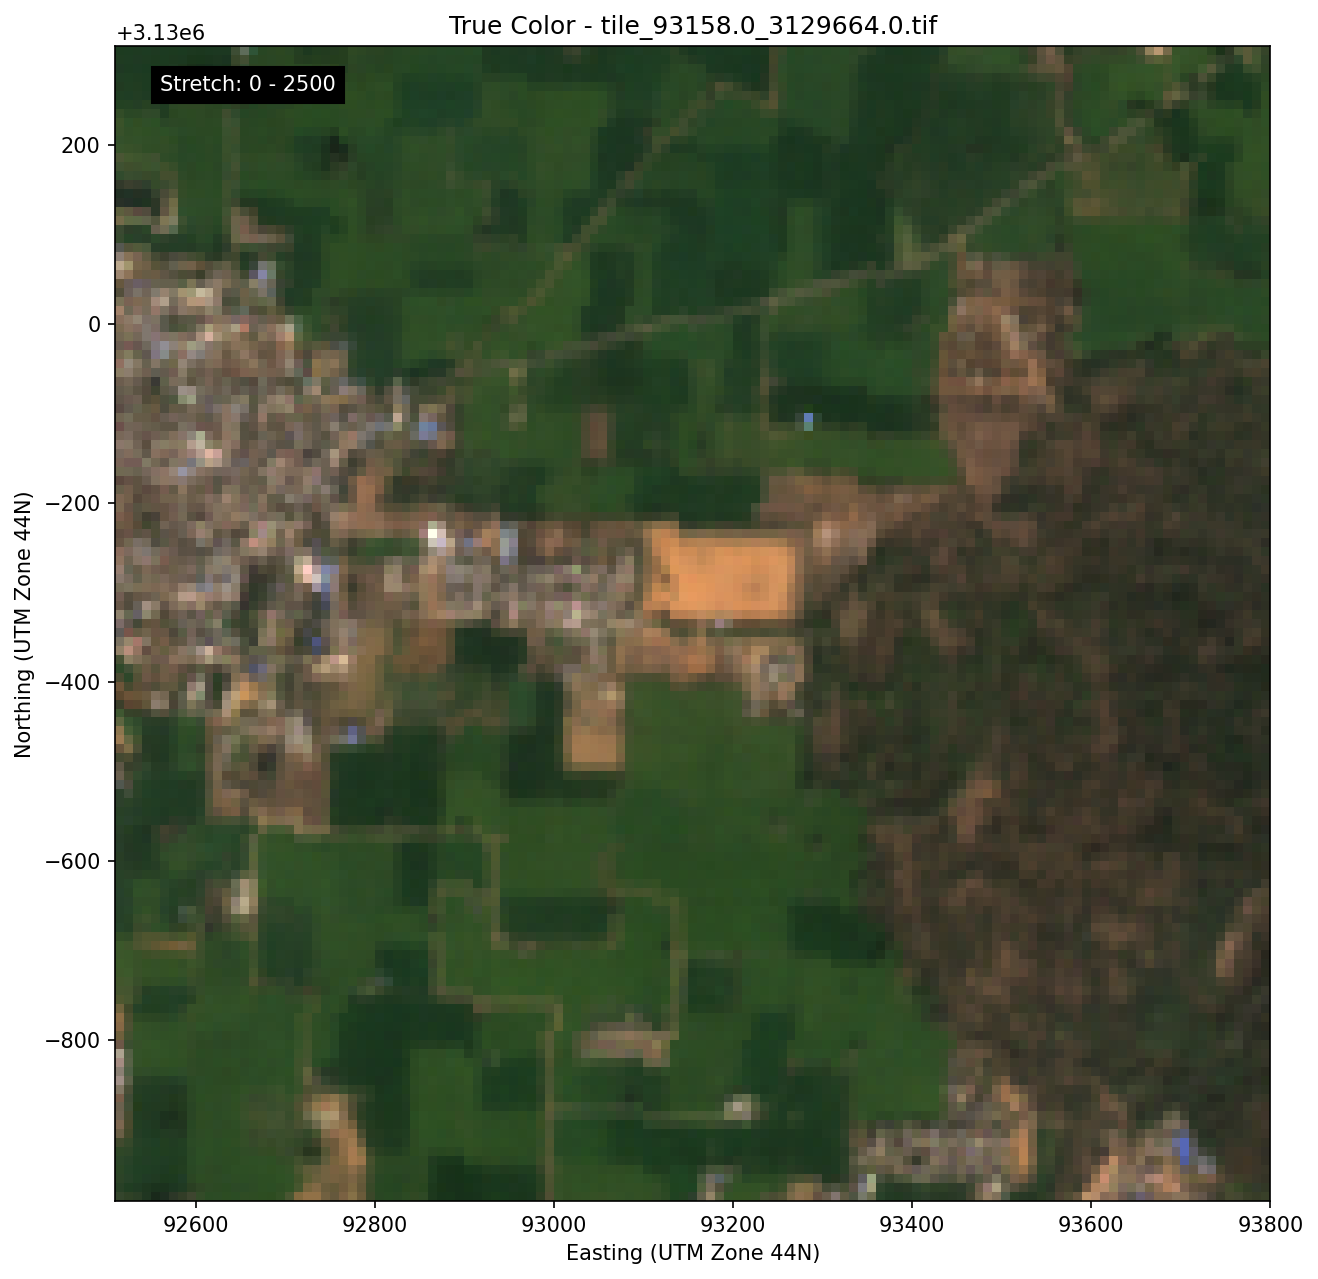


Finished plotting. Check the images for improved clarity.


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

FILE_NAMES = [
    'tile_93158.0_3125824.0.tif',
    'tile_93158.0_3127104.0.tif',
    'tile_93158.0_3128384.0.tif',
    'tile_93158.0_3129664.0.tif'
]

MAX_VAL_STRETCH = 2500

def plot_true_color_tile(file_name, max_stretch):

    if not os.path.exists(file_name):
        print(f"Skipping: File not found at '{file_name}'. Ensure all files are uploaded.")
        return

    try:
        with rasterio.open(file_name) as src:
            red = src.read(1)
            green = src.read(2)
            blue = src.read(3)

            rgb_composite = np.stack([red, green, blue], axis=-1)

            rgb_clipped = np.clip(rgb_composite, 0, max_stretch)

            rgb_normalized = (rgb_clipped / max_stretch) * 255

            rgb_final = rgb_normalized.astype(np.uint8)

            plt.figure(figsize=(10, 10), dpi=150)

            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

            plt.imshow(rgb_final,
                       extent=extent,
                       interpolation='none')

            plt.title(f"True Color - {file_name}")
            plt.xlabel("Easting (UTM Zone 44N)")
            plt.ylabel("Northing (UTM Zone 44N)")

            plt.text(src.bounds.left + 50, src.bounds.top - 50,
                     f"Stretch: 0 - {max_stretch}",
                     color='white', backgroundcolor='black', fontsize=10)

            plt.show()

    except rasterio.RasterioIOError as e:
        print(f"Error reading file '{file_name}': {e}. Check if the file is corrupted.")
    except Exception as e:
        print(f"An unexpected error occurred while processing '{file_name}': {e}")


print(f"Starting plot for {len(FILE_NAMES)} tiles with a 0 to {MAX_VAL_STRETCH} stretch...")
for file in FILE_NAMES:
    plot_true_color_tile(file, MAX_VAL_STRETCH)

print("\nFinished plotting. Check the images for improved clarity.")


**Problem-2**

In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rasterio numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 82.1 MB/s eta 0:00:00


In [ ]:
!pip install rasterio numpy pyproj

**2.a**

In [ ]:
import numpy as np
import rasterio
from rasterio.windows import Window
import os
import glob
from pyproj import CRS, Transformer, exceptions as pyproj_exceptions

PATCH_SIZE = 64
PAD_SIZE = 16
PATCH_FULL_SIDE = PATCH_SIZE + 2 * PAD_SIZE

LC_RASTER_DIR = '/content/drive/MyDrive/Delhi_Airshed_Tiles_JRF/'
OUTPUT_SAVE_PATH = 'extracted_patches.npz'

def extract_land_cover_patch(lc_src_handle, center_x, center_y, tile_crs):
    center_x_lc, center_y_lc = center_x, center_y

    if str(tile_crs) != str(lc_src_handle.crs):
        try:
            transformer = Transformer.from_crs(tile_crs, lc_src_handle.crs, always_xy=True)
            center_x_lc, center_y_lc = transformer.transform(center_x, center_y)
        except pyproj_exceptions.CRSError as e:
            return None
        except Exception :
            return None
    try:
        center_row, center_col = lc_src_handle.index(center_x_lc, center_y_lc)
    except Exception:
        return None

    row_off = int(center_row - (PATCH_FULL_SIDE / 2))
    col_off = int(center_col - (PATCH_FULL_SIDE / 2))

    desired_window = Window(col_off=col_off, row_off=row_off,
                            width=PATCH_FULL_SIDE, height=PATCH_FULL_SIDE)

    try:
        clamped_window = desired_window.intersection(Window(0, 0, lc_src_handle.width, lc_src_handle.height))
    except rasterio.windows.WindowError:
        return None

    if clamped_window.width <= 0 or clamped_window.height <= 0:
        return None

    shift_row = int(clamped_window.row_off - desired_window.row_off)
    shift_col = int(clamped_window.col_off - desired_window.col_off)

    lc_data = lc_src_handle.read(1, window=clamped_window)

    output_shape = (PATCH_FULL_SIDE, PATCH_FULL_SIDE)
    lc_patch = np.zeros(output_shape, dtype=lc_data.dtype)

    dest_row_end = shift_row + lc_data.shape[0]
    dest_col_end = shift_col + lc_data.shape[1]

    lc_patch[shift_row:dest_row_end, shift_col:dest_col_end] = lc_data

    return lc_patch

def get_center_points_for_tile(lc_src_handle):

    bbox = lc_src_handle.bounds
    center_x_native = (bbox.left + bbox.right) / 2
    center_y_native = (bbox.bottom + bbox.top) / 2
    tile_crs = lc_src_handle.crs

    print(f"NOTE: Using tile center: ({center_x_native:.2f}, {center_y_native:.2f}) in CRS {tile_crs.to_string()}")

    center_wgs84_x = 77.20
    center_wgs84_y = 28.60
    point_crs_wgs84 = CRS.from_epsg(4326)

    points_to_process = [
        (center_x_native, center_y_native, tile_crs),

        (center_wgs84_x, center_wgs84_y, point_crs_wgs84)
    ]
    return points_to_process


def process_all_tiles(lc_raster_dir, output_path):

    search_path = os.path.join(lc_raster_dir, '**', '*.tif')
    lc_tiles = glob.glob(search_path, recursive=True)

    if not lc_tiles:
        return

    print(f"Found {len(lc_tiles)} Land Cover tiles to process.")

    all_extracted_patches = []

    for tile_path in lc_tiles:
        try:
            with rasterio.open(tile_path) as lc_src:
                print(f"\n--- Processing Tile: {os.path.basename(tile_path)} ---")

                points_to_process = get_center_points_for_tile(lc_src)

                for i, (center_x, center_y, tile_crs) in enumerate(points_to_process):
                    patch = extract_land_cover_patch(lc_src, center_x, center_y, tile_crs)

                    if patch is not None:
                        all_extracted_patches.append(patch)

        except rasterio.RasterioIOError as e:
            print(f"Error opening raster file {tile_path}: {e}")
        except Exception as e:
            print(f"An unexpected error occurred while processing tile {tile_path}: {e}")

    if all_extracted_patches:
        print(f"Finished processing all tiles. Total patches extracted: {len(all_extracted_patches)}")
        np.savez_compressed(output_path, *all_extracted_patches)
        print(f"All patches saved to: {output_path}")


if __name__ == "__main__":
    process_all_tiles(LC_RASTER_DIR, OUTPUT_SAVE_PATH)

Found 606 Land Cover tiles to process.

--- Processing Tile: tile_93158.0_3130944.0.tif ---
NOTE: Using tile center: (93155.00, 3130945.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3125824.tif ---
NOTE: Using tile center: (93155.00, 3125825.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3127104.tif ---
NOTE: Using tile center: (93155.00, 3127105.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3128384.tif ---
NOTE: Using tile center: (93155.00, 3128385.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3129664.tif ---
NOTE: Using tile center: (93155.00, 3129665.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3130944.tif ---
NOTE: Using tile center: (93155.00, 3130945.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3132224.tif ---
NOTE: Using tile center: (93155.00, 3132225.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3133504.tif ---
NOTE: Using tile center: (93155.00, 3133505.00) in CRS EPSG:32644

--- Processing Tile: tile_93158_3134

**2.b-e**

In [ ]:
import numpy as np
import rasterio
from rasterio.windows import Window
import os
from pyproj import CRS, Transformer, exceptions as pyproj_exceptions
from scipy.stats import mode
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path

PATCH_SIZE = 128
PAD_SIZE = 0
PATCH_FULL_SIDE = PATCH_SIZE + 2 * PAD_SIZE

LC_RASTER_DIR = '/content/drive/MyDrive/Delhi_Airshed_Tiles_JRF'
TILE_DIR = '/content/drive/MyDrive/Delhi_Airshed_Tiles_JRF'
OUTPUT_SAVE_PATH = 'extracted_patches_and_labels_clean.npz'

ESA_TO_STANDARDIZED = {
    0: 0,
    10: 2, # Forest
    20: 4, # Shrubland
    30: 3, # Grassland
    90: 5, # Wetlands
    95: 5, # Mangroves
    100: 8, # Bare/Sparse
    40: 1, # Cropland
    50: 7, # Urban
    60: 8, # cloud
    80: 6, # Water
    70: 9, # Snow/Ice
    101: 0, # Permanent snow/ice
    102: 0, # Flooded vegetation
    103: 0, # Flooded bare soil
}
DEFAULT_LABEL = 0

def get_tile_info(tile_path):
    try:
        with rasterio.open(tile_path) as src:
            bounds = src.bounds
            center_x = (bounds.left + bounds.right) / 2
            center_y = (bounds.bottom + bounds.top) / 2
            tile_crs = src.crs
            return center_x, center_y, tile_crs
    except rasterio.RasterioIOError:
        return 77.20, 28.60, CRS.from_epsg(4326)

def get_center_points_for_tile(lc_src_handle):
    bbox = lc_src_handle.bounds
    center_x_native = (bbox.left + bbox.right) / 2
    center_y_native = (bbox.bottom + bbox.top) / 2
    tile_crs = lc_src_handle.crs

    center_wgs84_x = 77.20
    center_wgs84_y = 28.60
    point_crs_wgs84 = CRS.from_epsg(4326)

    return [(center_x_native, center_y_native, tile_crs), (center_wgs84_x, center_wgs84_y, point_crs_wgs84)]

In [ ]:
def calculate_patch_mode_label(lc_patch):
    valid_pixels = lc_patch[lc_patch > 0]

    if valid_pixels.size == 0:
        return DEFAULT_LABEL, 0

    try:
        counts = np.bincount(valid_pixels)
        esa_code = np.argmax(counts)
        mode_count = counts[esa_code]

        if mode_count == 1:
            return DEFAULT_LABEL, mode_count

    except Exception:
        return DEFAULT_LABEL, 0

    standardized_label = ESA_TO_STANDARDIZED.get(esa_code, DEFAULT_LABEL)
    return standardized_label, mode_count

def extract_land_cover_patch(lc_src_handle, center_x, center_y, tile_crs):
    center_x_lc, center_y_lc = center_x, center_y

    if str(tile_crs) != str(lc_src_handle.crs):
        try:
            transformer = Transformer.from_crs(tile_crs, lc_src_handle.crs, always_xy=True)
            center_x_lc, center_y_lc = transformer.transform(center_x, center_y)
        except (pyproj_exceptions.CRSError, Exception):
            return None
    try:
        center_row, center_col = lc_src_handle.index(center_x_lc, center_y_lc)
    except Exception:
        return None

    row_off = int(center_row - (PATCH_FULL_SIDE / 2))
    col_off = int(center_col - (PATCH_FULL_SIDE / 2))

    desired_window = Window(col_off=col_off, row_off=row_off,
                            width=PATCH_FULL_SIDE, height=PATCH_FULL_SIDE)

    try:
        clamped_window = desired_window.intersection(Window(0, 0, lc_src_handle.width, lc_src_handle.height))
    except rasterio.windows.WindowError:
        return None

    if clamped_window.width <= 0 or clamped_window.height <= 0:
        return None

    shift_row = int(clamped_window.row_off - desired_window.row_off)
    shift_col = int(clamped_window.col_off - desired_window.col_off)

    lc_data = lc_src_handle.read(1, window=clamped_window)

    output_shape = (PATCH_FULL_SIDE, PATCH_FULL_SIDE)
    lc_patch = np.zeros(output_shape, dtype=lc_data.dtype)

    dest_row_end = shift_row + lc_data.shape[0]
    dest_col_end = shift_col + lc_data.shape[1]

    lc_patch[shift_row:dest_row_end, shift_col:dest_col_end] = lc_data

    return lc_patch

In [ ]:
def visualize_distribution(labels, label_map):
    unique, counts = np.unique(labels, return_counts=True)
    distribution = dict(zip(unique, counts))

    sorted_label_ids = sorted(list(label_map.keys()))
    full_names = [label_map.get(i, f"Unknown ({i})") for i in sorted_label_ids]
    full_counts = [distribution.get(i, 0) for i in sorted_label_ids]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(full_names, full_counts, color='skyblue')

    plt.xlabel('Standardized Land Cover Class')
    plt.ylabel('Number of Patches')
    plt.title('Class Distribution of Extracted Land Cover Patches')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom')

    plt.show()

    print(f"Total patches extracted: {len(labels)}")

In [ ]:
def process_all_tiles(lc_raster_dir, s2_tile_dir, output_path):
    STANDARD_LABEL_MAP = {
        0: 'No Data/Skipped', 1: 'Crops', 2: 'Forest', 3: 'Grassland', 4: 'Shrubland',
        5: 'Wetlands', 6: 'Water', 7: 'Urban', 8: 'Bare/Sparse', 9: 'Snow/Ice', 10: 'Cloud'
    }

    lc_file_name = '/content/worldcover_bbox_delhi_ncr_2021.tif'
    lc_file_path = os.path.join(lc_raster_dir, lc_file_name)

    all_tif_files = glob.glob(os.path.join(s2_tile_dir, '**', '*.tif'), recursive=True)

    s2_tile_files = [f for f in all_tif_files if Path(f).name != lc_file_name]

    if not os.path.exists(lc_file_path):
        print(f"FATAL ERROR: Land Cover file '{lc_file_path}' not found.")
        return

    if not s2_tile_files:
        print(f"Error: No Sentinel-2 tile GeoTIFF files found in {s2_tile_dir}.")
        return

    all_extracted_patches = []
    all_labels = []

    try:
        lc_src = rasterio.open(lc_file_path)
    except rasterio.RasterioIOError as e:
        print(f"FATAL ERROR: Could not open Land Cover file '{lc_file_path}': {e}")
        return

    for tile_path in s2_tile_files:
        tile_path = Path(tile_path)

        center_x, center_y, tile_crs = get_tile_info(tile_path)

        if center_x is None or tile_crs is None:
            continue

        lc_patch = extract_land_cover_patch(lc_src, center_x, center_y, tile_crs)

        if lc_patch is not None:
            label, _ = calculate_patch_mode_label(lc_patch)
            all_extracted_patches.append(lc_patch)
            all_labels.append(label)

    lc_src.close()

    if all_extracted_patches:
        patches_array = np.array(all_extracted_patches)
        labels_array = np.array(all_labels)

        unique_labels, label_counts = np.unique(labels_array, return_counts=True)
        single_sample_labels = unique_labels[label_counts < 2]

        if len(patches_array) >= 2:
            try:
                train_patches, test_patches, train_labels, test_labels = train_test_split(
                    patches_array,
                    labels_array,
                    test_size=0.4,
                    random_state=42,
                    stratify=labels_array
                )

                np.savez_compressed(
                    output_path,
                    train_patches=train_patches,
                    test_patches=test_patches,
                    train_labels=train_labels,
                    test_labels=test_labels
                )
                print(f"Train set size: {len(train_patches)} patches (60%)")
                print(f"Test set size: {len(test_patches)} patches (40%)")

            except ValueError as e:
                print(f"FATAL ERROR during train/test split: {e}")

                train_patches, test_patches, train_labels, test_labels = train_test_split(
                    patches_array, labels_array, test_size=0.4, random_state=42
                )
                np.savez_compressed(
                    output_path, train_patches=train_patches, test_patches=test_patches,
                    train_labels=train_labels, test_labels=test_labels
                )
                print(f"Train set size: {len(train_patches)}")
                print(f"Test set size: {len(test_patches)}")

        else:
            print(f"Not enough patches ({len(patches_array)}) to perform a train/test split.")

        visualize_distribution(labels_array, STANDARD_LABEL_MAP)

Train set size: 359 patches (60%)
Test set size: 240 patches (40%)


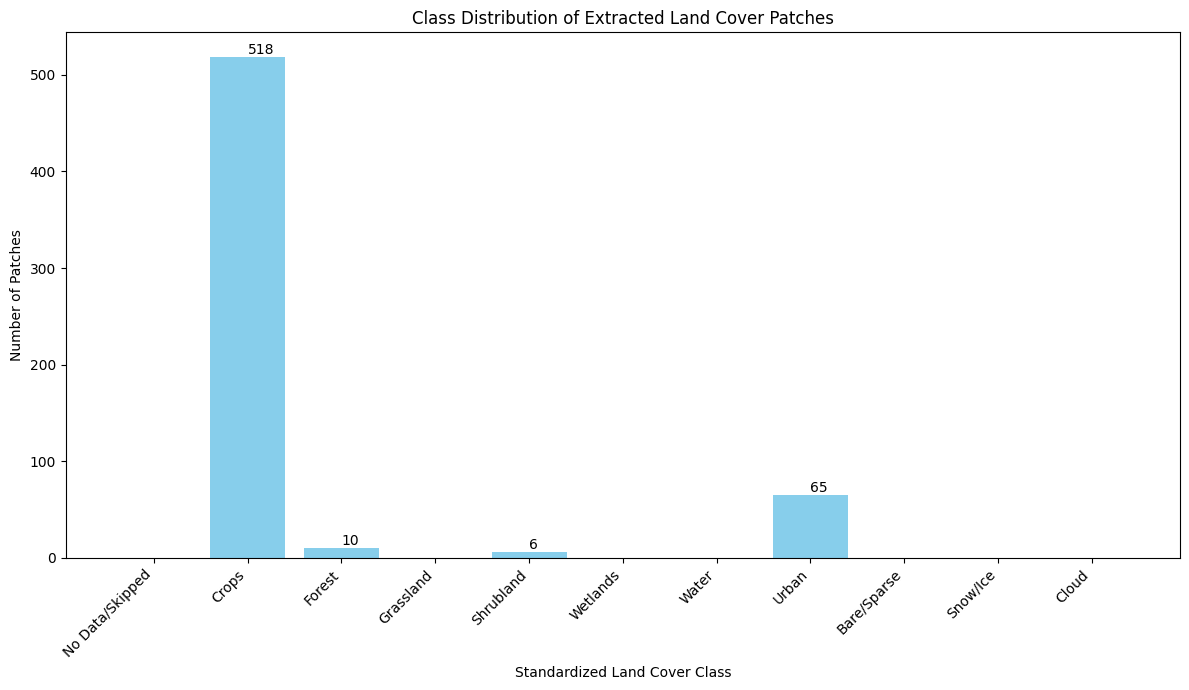

Total patches extracted: 599


In [ ]:
if __name__ == "__main__":
    process_all_tiles(LC_RASTER_DIR, TILE_DIR, OUTPUT_SAVE_PATH)

* The distribution is highly imbalanced, as the Crops class accounts for over 86% of the samples

**Problem-3**

In [ ]:
import numpy as np

DATA_FILE_PATH = 'extracted_patches_and_labels_clean.npz'

try:
    loaded_data = np.load(DATA_FILE_PATH)

    train_patches = loaded_data['train_patches']
    test_patches = loaded_data['test_patches']
    train_labels = loaded_data['train_labels']
    test_labels = loaded_data['test_labels']

    print("Data loaded successfully.")
    print(f"Train patches shape: {train_patches.shape}")
    print(f"Test patches shape: {test_patches.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Test labels shape: {test_labels.shape}")

except FileNotFoundError:
    print(f"Error: The file '{DATA_FILE_PATH}' was not found.")
except KeyError as e:
    print(f"Error: Missing expected key in the .npz file: {e}")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")


Data loaded successfully.
Train patches shape: (359, 128, 128)
Test patches shape: (240, 128, 128)
Train labels shape: (359,)
Test labels shape: (240,)


In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        dummy_input = torch.randn(1, 1, 128, 128)
        dummy_output = self.pool2(self.relu2(self.conv2(self.pool1(self.relu1(self.conv1(dummy_input))))))
        flattened_size = dummy_output.view(dummy_output.size(0), -1).size(1)

        self.fc1 = nn.Linear(flattened_size, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

NUM_CLASSES = 11
model = SimpleCNN(num_classes=NUM_CLASSES)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=11, bias=True)
)


In [ ]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 10

batch_size = 32

print(f"Loss Function: {type(criterion).__name__}")
print(f"Optimizer: {type(optimizer).__name__} with Learning Rate: {learning_rate}")
print(f"Number of Epochs: {num_epochs}")
print(f"Batch Size: {batch_size}")

Loss Function: CrossEntropyLoss
Optimizer: Adam with Learning Rate: 0.001
Number of Epochs: 10
Batch Size: 32


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_patches_tensor = torch.tensor(train_patches, dtype=torch.float32).unsqueeze(1)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)

train_dataset = TensorDataset(train_patches_tensor, train_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")

print(f"Starting training for {num_epochs} epochs...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("Training finished.")


Using device: cpu
Starting training for 10 epochs...
Epoch [1/10], Loss: 14.7742
Epoch [2/10], Loss: 1.1396
Epoch [3/10], Loss: 0.4881
Epoch [4/10], Loss: 0.3200
Epoch [5/10], Loss: 0.1804
Epoch [6/10], Loss: 0.1675
Epoch [7/10], Loss: 0.1145
Epoch [8/10], Loss: 0.1477
Epoch [9/10], Loss: 0.0766
Epoch [10/10], Loss: 0.0425
Training finished.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    average_loss = running_loss / len(data_loader)
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0

    return average_loss, accuracy

test_patches_tensor = torch.tensor(test_patches, dtype=torch.float32).unsqueeze(1)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)
test_dataset = TensorDataset(test_patches_tensor, test_labels_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loss, train_accuracy = evaluate_model(model, train_loader, criterion, device)
print(f"Training Set - Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")

test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
print(f"Testing Set - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}")

Training Set - Loss: 0.0409, Accuracy: 0.9944
Testing Set - Loss: 0.8251, Accuracy: 0.7833


In [ ]:
import torch
import numpy as np
from sklearn.metrics import f1_score
from torchmetrics import F1Score

def custom_f1_score_implementation(y_true, y_pred, labels, average='weighted'):

    return f1_score(y_true, y_pred, labels=labels, average=average, zero_division=0)

def calculate_f1_scores(model, data_loader, device, num_classes):

    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, dim=1)

            all_labels.append(labels.cpu().numpy())
            all_predictions.append(predicted.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_predictions = np.concatenate(all_predictions)

    present_labels = np.unique(all_labels)

    custom_f1 = custom_f1_score_implementation(all_labels, all_predictions, labels=present_labels, average='weighted')
    print(f"Custom F1 Score (Weighted, Present Classes): {custom_f1:.4f}")

    all_labels_tensor = torch.tensor(all_labels, dtype=torch.long)
    all_predictions_tensor = torch.tensor(all_predictions, dtype=torch.long)

    tm_f1_metric = F1Score(task='multiclass', num_classes=num_classes, average='weighted').to(device) # Use weighted average for comparison and move to device
    tm_f1 = tm_f1_metric(all_predictions_tensor.to(device), all_labels_tensor.to(device)) # Move tensors to device

    print(f"TorchMetrics F1 Score (Weighted): {tm_f1.item():.4f}") # Use .item() to get scalar value

    print(f"Comparison: Custom F1 Score ({custom_f1:.4f}) vs. TorchMetrics F1 Score ({tm_f1.item():.4f}).")


print("\n--- Calculating F1 Scores for Training Set ---")
calculate_f1_scores(model, train_loader, device, NUM_CLASSES)

print("\n--- Calculating F1 Scores for Testing Set ---")
calculate_f1_scores(model, test_loader, device, NUM_CLASSES)


--- Calculating F1 Scores for Training Set ---
Custom F1 Score (Weighted, Present Classes): 0.9945
TorchMetrics F1 Score (Weighted): 0.9945
Comparison: Custom F1 Score (0.9945) vs. TorchMetrics F1 Score (0.9945).

--- Calculating F1 Scores for Testing Set ---
Custom F1 Score (Weighted, Present Classes): 0.7671
TorchMetrics F1 Score (Weighted): 0.7671
Comparison: Custom F1 Score (0.7671) vs. TorchMetrics F1 Score (0.7671).


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

REVERSE_LABEL_MAP = {
    0: 'No Data/Skipped', 1: 'Cropland', 2: 'Tree Cover', 3: 'Grassland', 4: 'Shrubland',
    5: 'Wetlands', 6: 'Water', 7: 'Built-up', 8: 'Bare/Sparse', 9: 'Snow/Ice', 10: 'Cloud'
}

model.eval()

all_test_labels = []
all_test_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, dim=1)

        all_test_labels.append(labels.cpu().numpy())
        all_test_predictions.append(predicted.cpu().numpy())

all_test_labels = np.concatenate(all_test_labels)
all_test_predictions = np.concatenate(all_test_predictions)

unique_test_labels = np.unique(all_test_labels)

cm = confusion_matrix(all_test_labels, all_test_predictions, labels=unique_test_labels)

print("\n--- Confusion Matrix for Test Set ---")

present_target_names = [REVERSE_LABEL_MAP[label] for label in unique_test_labels]

cm_header = " | " + " | ".join(present_target_names) + " |"
print("-" * len(cm_header))
print(cm_header)
print("-" * len(cm_header))

for i, row in enumerate(cm):
    row_str = f"{present_target_names[i]} | " + " | ".join(map(str, row)) + " |"
    print(row_str)
print("-" * len(cm_header))

print("\n--- Explanation of Confusion Matrix ---")
print("- **Rows** represent the **actual** (true) land cover classes.")
print("- **Columns** represent the **predicted** land cover classes.")
print("- The values on the **main diagonal** indicate the number of samples that were **correctly classified** (True Positives) for each class.")
print("- The values **off the main diagonal** indicate the number of samples that were **misclassified**. For example, a value in row 'A' and column 'B' means samples that were actually class 'A' were predicted as class 'B'.")
print(f"- This matrix only shows classes present in the test set ({len(unique_test_labels)} classes).")


--- Confusion Matrix for Test Set ---
-------------------------------------------------
 | Cropland | Tree Cover | Shrubland | Built-up |
-------------------------------------------------
Cropland | 187 | 0 | 0 | 21 |
Tree Cover | 4 | 0 | 0 | 0 |
Shrubland | 1 | 0 | 0 | 1 |
Built-up | 25 | 0 | 0 | 1 |
-------------------------------------------------

--- Explanation of Confusion Matrix ---
- **Rows** represent the **actual** (true) land cover classes.
- **Columns** represent the **predicted** land cover classes.
- The values on the **main diagonal** indicate the number of samples that were **correctly classified** (True Positives) for each class.
- The values **off the main diagonal** indicate the number of samples that were **misclassified**. For example, a value in row 'A' and column 'B' means samples that were actually class 'A' were predicted as class 'B'.
- This matrix only shows classes present in the test set (4 classes).


Total test samples: 240
Number of correct predictions: 188
Number of incorrect predictions: 52

--- Visualizing 5 Correct Predictions ---


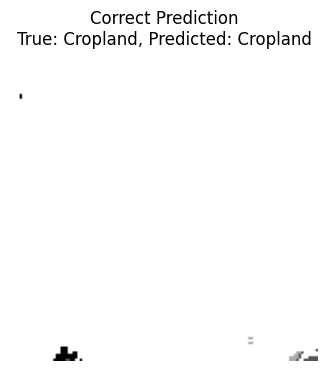

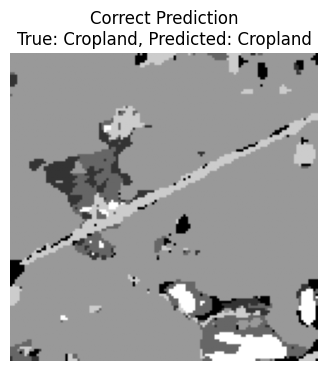

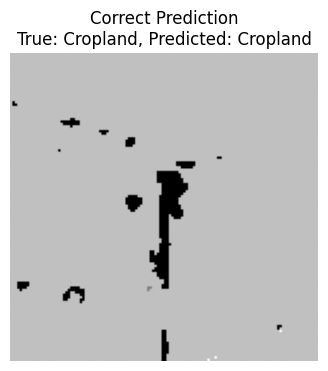

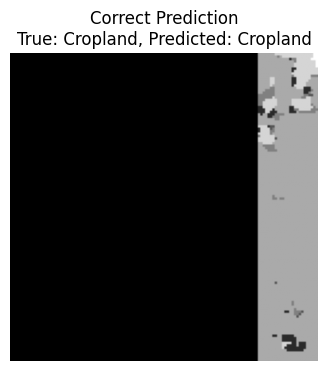

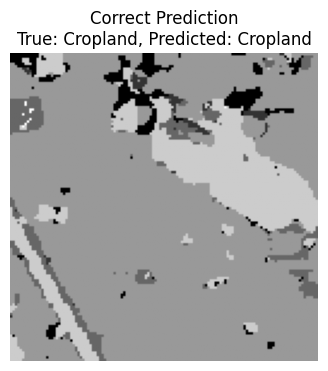


--- Visualizing 5 Incorrect Predictions ---


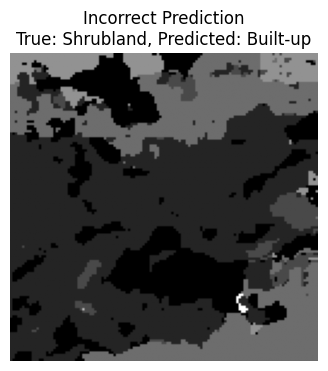

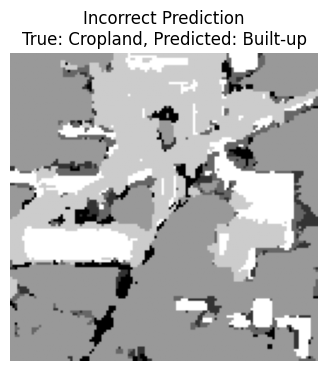

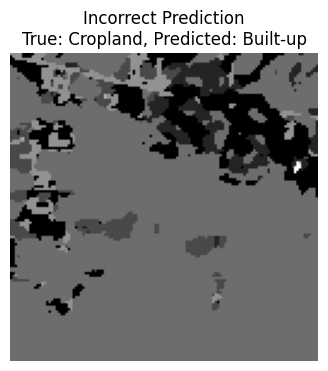

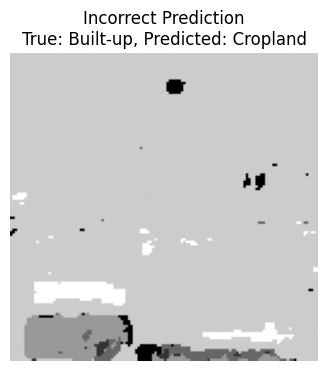

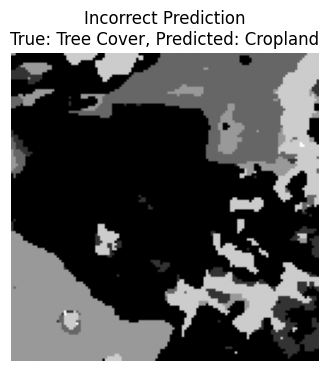

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

is_correct = (all_test_labels == all_test_predictions)
correct_indices = np.where(is_correct)[0]
incorrect_indices = np.where(~is_correct)[0]

print(f"Total test samples: {len(all_test_labels)}")
print(f"Number of correct predictions: {len(correct_indices)}")
print(f"Number of incorrect predictions: {len(incorrect_indices)}")

num_samples_to_plot = 5
sample_correct = np.random.choice(correct_indices, min(num_samples_to_plot, len(correct_indices)), replace=False)
sample_incorrect = np.random.choice(incorrect_indices, min(num_samples_to_plot, len(incorrect_indices)), replace=False)

REVERSE_LABEL_MAP = {
    0: 'No Data/Skipped', 1: 'Cropland', 2: 'Tree Cover', 3: 'Grassland', 4: 'Shrubland',
    5: 'Wetlands', 6: 'Water', 7: 'Built-up', 8: 'Bare/Sparse', 9: 'Snow/Ice', 10: 'Cloud'
}

print(f"\n--- Visualizing {len(sample_correct)} Correct Predictions ---")
for i in sample_correct:
    patch_index = i
    image_patch = test_patches[patch_index]
    true_label = all_test_labels[patch_index]
    predicted_label = all_test_predictions[patch_index]

    true_class_name = REVERSE_LABEL_MAP.get(true_label, f"Unknown ({true_label})")
    predicted_class_name = REVERSE_LABEL_MAP.get(predicted_label, f"Unknown ({predicted_label})")

    plt.figure(figsize=(4, 4))
    plt.imshow(image_patch.squeeze(), cmap='gray')
    plt.title(f"Correct Prediction\nTrue: {true_class_name}, Predicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()

print(f"\n--- Visualizing {len(sample_incorrect)} Incorrect Predictions ---")
for i in sample_incorrect:
    patch_index = i
    image_patch = test_patches[patch_index]
    true_label = all_test_labels[patch_index]
    predicted_label = all_test_predictions[patch_index]

    true_class_name = REVERSE_LABEL_MAP.get(true_label, f"Unknown ({true_label})")
    predicted_class_name = REVERSE_LABEL_MAP.get(predicted_label, f"Unknown ({predicted_label})")

    plt.figure(figsize=(4, 4))
    plt.imshow(image_patch.squeeze(), cmap='gray')
    plt.title(f"Incorrect Prediction\nTrue: {true_class_name}, Predicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()
